In [19]:
import os
import shutil

checkpoint_folder = "/content/sample_data/imagedataset/.ipynb_checkpoints"

if os.path.exists(checkpoint_folder):
    shutil.rmtree(checkpoint_folder)
    print("Deleted .ipynb_checkpoints")
else:
    print("Folder not found")

Folder not found


In [20]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_data_dir = "/content/sample_data/imagedataset"
validation_data_dir = "/content/sample_data/imagedataset"

# Parameters
img_width = 150
img_height = 150
batch_size = 10
epochs = 20

# -----------------------------
# Create CNN Model
# -----------------------------
def create_model():

    model = models.Sequential([

        layers.Input(shape=(img_width, img_height, 3)),

        layers.Conv2D(16, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),

        layers.GlobalAveragePooling2D(),

        layers.Dense(32, activation="relu"),

        layers.Dropout(0.3),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# -----------------------------
# Data Augmentation
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# -----------------------------
# Validation Data
# -----------------------------
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

# -----------------------------
# Load Training Data
# -----------------------------
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

# -----------------------------
# Load Validation Data
# -----------------------------
validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

# -----------------------------
# Create Model
# -----------------------------
model = create_model()

model.summary()

Found 10 images belonging to 2 classes.
Found 10 images belonging to 2 classes.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,697 (100.38 KB)

 Trainable params: 25,697 (100.38 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
import os

print(os.listdir('/content/sample_data/imagedataset'))

['male', 'female']


In [22]:
# Create the CNN model
model = create_model()

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

# Save the model
model.save("my_model.keras")   # Recommended format

print("Training and validation completed!")

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4000 - loss: 0.6970 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step - accuracy: 0.4000 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step - accuracy: 0.3000 - loss: 0.6980 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step - accuracy: 0.5000 - loss: 0.6980 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6000 - loss: 0.6911 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step - accuracy: 0.6000 - loss: 0.6854 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step - accuracy: 0.8000 - loss: 0.6858 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step - accuracy: 0.6000 - loss: 0.6957 - val_accuracy: 0.5000 - val_loss: 0.692

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Raw Prediction: 0.5068495869636536


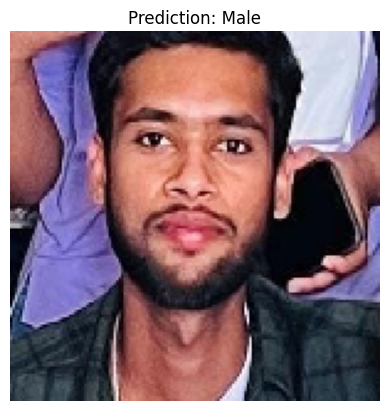

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# -----------------------------
# Load the trained model
# -----------------------------
model = load_model("/content/my_model.keras")   # Change path if needed

# -----------------------------
# Load and preprocess the test image
# -----------------------------
img_path = "/content/sample_data/testdataset/WhatsApp Image 2026-07-06 at 22.23.12 (2).jpeg"

img = image.load_img(img_path, target_size=(150, 150))

x = image.img_to_array(img)
x = x / 255.0
x = np.expand_dims(x, axis=0)

# -----------------------------
# Predict
# -----------------------------
prediction = model.predict(x)

probability = float(prediction[0][0])

print("Raw Prediction:", probability)

# -----------------------------
# IMPORTANT:
# Check train_generator.class_indices first!
# -----------------------------

if probability >= 0.5:
    result = "Male"
else:
    result = "Female"

# -----------------------------
# Display Result
# -----------------------------
plt.imshow(img)
plt.title(f"Prediction: {result}")
plt.axis("off")
plt.show()

In [25]:
print(prediction)
print(prediction.shape)

[[0.5068496]]
(1, 1)
